In [317]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [318]:
df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\Medical Insurance\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [319]:
df.shape

(1338, 7)

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [321]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [322]:
df.duplicated().sum()

np.int64(1)

In [323]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [324]:
df.drop_duplicates(inplace=True)

In [325]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [326]:
df.describe(include='object')

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [327]:
df["sex"] = df["sex"].replace({"male":1,"female":0})
df["smoker"] = df["smoker"].replace({"yes":1,"no":0})
df = pd.get_dummies(df, columns=["region"], drop_first=True)

C:\Users\SUYASH\AppData\Local\Temp\ipykernel_17908\691179720.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex"] = df["sex"].replace({"male":1,"female":0})
C:\Users\SUYASH\AppData\Local\Temp\ipykernel_17908\691179720.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoker"] = df["smoker"].replace({"yes":1,"no":0})


In [328]:
df["region_northwest"] = df["region_northwest"].replace({"True":1,"False":0})
df["region_southeast"] = df["region_southeast"].replace({"True":1,"False":0})
df["region_southwest"] = df["region_southwest"].replace({"True":1,"False":0})

In [329]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


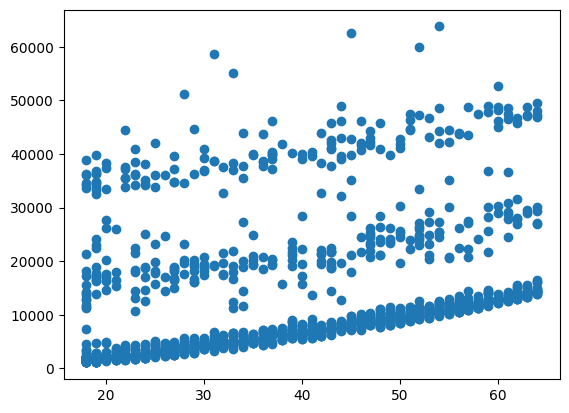

In [330]:
plt.scatter(x=df["age"],y=df["charges"])

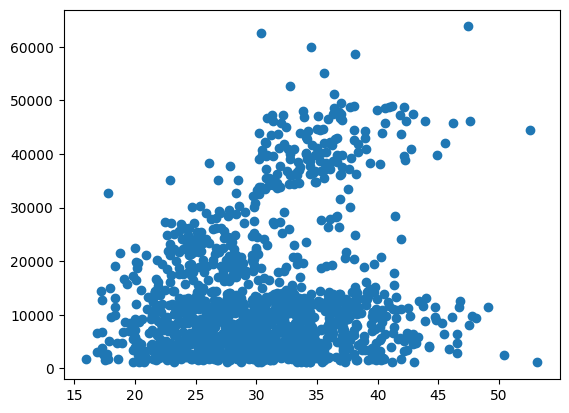

In [331]:
plt.scatter(x=df["bmi"],y=df["charges"])

In [332]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')

In [333]:
X = df.drop("charges", axis=1)
y = df["charges"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [334]:
print(type(X_train), X_train.shape)
print(type(X_test), X_test.shape)

print(type(y_train), y_train.shape)
print(type(y_test), y_test.shape)

<class 'pandas.core.frame.DataFrame'> (1069, 8)
<class 'pandas.core.frame.DataFrame'> (268, 8)
<class 'pandas.core.series.Series'> (1069,)
<class 'pandas.core.series.Series'> (268,)


In [335]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [336]:
# Feature Scaling
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Convert targets once
y_train = y_train.to_numpy(dtype=np.float64)
y_test = y_test.to_numpy(dtype=np.float64)

y_train_sc = scaler.fit_transform(
    y_train.reshape(-1,1)
)

y_test_sc = scaler.transform(
    y_test.reshape(-1,1)
)

# Linear Regresion using numpy from scratch

In [337]:
def predict(X,W,b):
    return np.dot(X,W) + b

In [338]:
def compute_cost(X,y, W, b):
    m = len(X)
    y_pred = predict(X, W, b)
    cost = (1/(2*m)) * np.sum((y_pred - y)**2)
    return cost

In [339]:
def compute_gradient(X, y, W, b):

    m = len(X)

    y_pred = np.dot(X, W) + b

    error = y_pred - y

    dW = (1/m) * np.dot(X.T, error)
    db = (1/m) * np.sum(error)

    return dW, db

In [340]:
def gradient_descent(X,y,W,b, learning_rate, iterations):
    cost_history = []

    for i in range(iterations):

        # Compute gradients
        dW, db = compute_gradient(X, y, W, b)

        # Update parameters
        W = W - learning_rate * dW
        b = b - learning_rate * db

        # Save cost
        cost = compute_cost(X, y, W, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return W, b, cost_history    

In [341]:
m, n = X_train_sc.shape

# Initialize parameters
W = np.zeros(n)
b = 0

# Hyperparameters
learning_rate = 1
iterations = 500

# Train
W, b, cost_history = gradient_descent(
    X_train_sc,
    y_train,
    W,
    b,
    learning_rate,
    iterations
)

Iteration 0: Cost = 20107406.6485
Iteration 100: Cost = 18489930.4524
Iteration 200: Cost = 18489930.4524
Iteration 300: Cost = 18489930.4524
Iteration 400: Cost = 18489930.4524


In [342]:
print("W: ",W)
print("b: ",b)

W:  [3472.97555343  -50.74967467 1927.82825101  636.5011853  9234.34248701
 -168.94443943 -371.7808097  -284.61039635]
b:  13030.203369289055


In [343]:
def r2_score(y,y_pred):
    ss_total = np.sum((y - np.mean(y))**2) 
                                           
    ss_residual = np.sum((y - y_pred)**2) 
    
    r2 = 1 - (ss_residual/ss_total) 
      
    return r2 

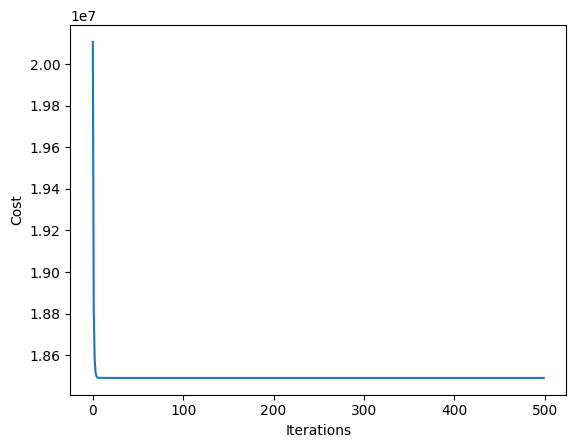

In [344]:

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

# linear Regression using normal equation method

In [345]:
def normal_equation(X, y):

    X_bias = np.c_[np.ones((X.shape[0],1)), X]

    theta = np.linalg.pinv(X_bias) @ y

    b = theta[0]
    W = theta[1:]

    return W, b

In [346]:
W, b = normal_equation(X_train_sc, y_train)

In [347]:
print("W: ",W)
print("b: ",b)

W:  [3472.97555343  -50.74967467 1927.82825101  636.5011853  9234.34248701
 -168.94443943 -371.7808097  -284.61039635]
b:  13030.20336928906


In [348]:
y_pred = predict(X_test_sc, W, b)

r2 = r2_score(y_test, y_pred)

print(r2)

0.8069287081198013


# Linear Regression using sklearn library

In [349]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_sc, y_train)
model.predict(X_test_sc)

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

In [350]:
#Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 35478020.675235584
R-squared: 0.8069287081198013
Mean Absolute Error: 4177.045561036326


# Linear Regression using ridge regression

In [351]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

y_pred_ridge = ridge.predict(X_test_sc)

print("R2 Score (Ridge):", r2_score(y_test, y_pred_ridge))

R2 Score (Ridge): 0.8067412087126401


# Linear Regression using lasso regression

In [352]:
#Trying Lasso Regression which can perform feature selection by shrinking some coefficients to zero, which can help in reducing multicollinearity and improving model interpretability
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_sc, y_train)

y_pred_lasso = lasso.predict(X_test_sc)

print("R2 Score (Lasso):", r2_score(y_test, y_pred_lasso))

R2 Score (Lasso): 0.8069286682567608


# Linear Regression using neural network (MLPRegressor)

In [353]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_sc = y_scaler.fit_transform(
    y_train.reshape(-1,1)
)

y_test_sc = y_scaler.transform(
    y_test.reshape(-1,1)
)

In [354]:
def initialize_parameter(input_size, hidden1, hidden2, output_size):
    np.random.seed(42)  # For reproducibility
    w1 = np.random.randn(input_size, hidden1) * np.sqrt(2/input_size)
    b1 = np.zeros((1, hidden1))
    
    w2 = np.random.randn(hidden1, hidden2) * np.sqrt(2/hidden1)
    b2 = np.zeros((1,hidden2))
    
    w3 = np.random.randn(hidden2, output_size) * np.sqrt(2/hidden2)
    b3 = np.zeros((1,output_size))
    
    parameters = {
        "w1" : w1,
        "b1" : b1,
        "w2" : w2,
        "b2" : b2,
        "w3" : w3,
        "b3" : b3
    }
    
    return parameters

In [355]:
def relu(z):
    return np.maximum(0,z)

In [356]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

In [357]:
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

In [358]:
def forward_propagation(X, parameters):
    w1 = parameters["w1"]
    b1 = parameters["b1"]
    w2 = parameters["w2"]
    b2 = parameters["b2"]
    w3 = parameters["w3"]
    b3 = parameters["b3"]
    
    #layer 1
    z1 = np.dot(X,w1) + b1
    A1 = leaky_relu(z1)
    
    #layer 2
    z2 = np.dot(A1,w2) + b2
    A2 = leaky_relu(z2)
    
    #output layer
    z3 = np.dot(A2, w3) + b3
    y_pred = z3
    
    cache = {
        "z1" : z1,
        "A1" : A1,
        "z2" : z2,
        "A2" : A2,
        "z3" : z3
    }
    return y_pred, cache

In [359]:
def compute_cost(y, y_pred):

    m = len(y)

    cost = np.sum((y_pred - y.reshape(-1,1))**2)/(2*m)

    return cost

In [360]:
def backward_propagation(X, y, parameters, cache):
    m = X.shape[0]
    w2 = parameters["w2"]
    w3 = parameters["w3"]
    
    A1 = cache["A1"]
    A2 = cache["A2"]
    
    z1 = cache["z1"]
    z2 = cache["z2"]
    
    y_pred = cache["z3"]
    
    y = y.reshape(-1,1)
    
    #output layer
    dz3 = (y_pred - y)
    dw3 = np.dot(A2.T, dz3) / m
    db3 = np.sum(dz3, axis=0, keepdims=True) / m
    
    #hidden layer 2
    dA2 = np.dot(dz3, w3.T)
    dz2 = dA2 * leaky_relu_derivative(z2)
    
    dw2 = np.dot(A1.T, dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    
    #hidden layer 1
    dA1 = np.dot(dz2, w2.T)
    dz1 = dA1 * leaky_relu_derivative(z1)
    
    dw1 = np.dot(X.T, dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    
    gradients = {
        "dw1" : dw1,
        "db1" : db1,
        "dw2" : dw2,
        "db2" : db2,
        "dw3" : dw3,
        "db3" : db3
    } 
    
    
    return gradients
    

In [361]:
def update_parameters(parameters, gradients, learning_rate):
    parameters["w1"] -= learning_rate * gradients["dw1"]
    parameters["b1"] -= learning_rate * gradients["db1"]
    
    parameters["w2"] -= learning_rate * gradients["dw2"]
    parameters["b2"] -= learning_rate * gradients["db2"]
    
    parameters["w3"] -= learning_rate * gradients["dw3"]
    parameters["b3"] -= learning_rate * gradients["db3"]
    
    return parameters

In [362]:
def train_model(X,y, hidden1=16, hidden2=8, learning_rate=0.01, iterations=5000):
    input_size = X.shape[1]
    output_size = 1
    
    parameters = initialize_parameter(
        input_size,
        hidden1,
        hidden2,
        output_size
    )
    
    cost_history = []
    
    for i in range(iterations):
        y_pred, cache = forward_propagation(X, parameters)
        cost = compute_cost(y, y_pred)
        gradients = backward_propagation(
            X,y, parameters, cache
        )
        parameters = update_parameters(
            parameters, gradients, learning_rate
        )
        
        cost_history.append(cost)
        
        if i % 500 == 0:
            print(f"Iterations {i}: cost = {cost:.4f}")
            
    return parameters, cost_history

In [363]:
def predict(X, parameters):

    y_pred, _ = forward_propagation(X, parameters)

    return y_pred

In [364]:
def r2_score(y, y_pred):

    y = y.reshape(-1,1)

    ss_total = np.sum((y - np.mean(y))**2)

    ss_residual = np.sum((y - y_pred)**2)

    return 1 - (ss_residual/ss_total)

In [365]:
parameters, history = train_model(
    X_train_sc,
    y_train_sc,
    hidden1=16,
    hidden2=8,
    learning_rate=0.1,
    iterations=5000
)

Iterations 0: cost = 1.2062
Iterations 500: cost = 0.0845
Iterations 1000: cost = 0.0797
Iterations 1500: cost = 0.0773
Iterations 2000: cost = 0.0755
Iterations 2500: cost = 0.0740
Iterations 3000: cost = 0.0729
Iterations 3500: cost = 0.0714
Iterations 4000: cost = 0.0699
Iterations 4500: cost = 0.0685


In [366]:
y_pred_sc = predict(
    X_test_sc,
    parameters
)
y_pred = y_scaler.inverse_transform(
    y_pred_sc
)
print(r2_score(y_test, y_pred))

0.8835205665885482


In [367]:
print("Prediction Min:", y_pred.min())
print("Prediction Max:", y_pred.max())
print("Prediction Mean:", y_pred.mean())

print("Actual Min:", y_test.min())
print("Actual Max:", y_test.max())
print("Actual Mean:", y_test.mean())

Prediction Min: 542.8659105514307
Prediction Max: 49888.11356849256
Prediction Mean: 14191.544991955227
Actual Min: 1131.5066
Actual Max: 63770.42801
Actual Mean: 14272.007559287313


In [368]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

mlp.fit(X_train_sc, y_train_sc.ravel())

pred_sc = mlp.predict(X_test_sc)

pred = y_scaler.inverse_transform(pred_sc.reshape(-1,1))

print(r2_score(y_test, pred))

0.8849852381006086


# Insurance Charges Prediction using Machine Learning & Neural Network (From Scratch)

## Project Title

**Insurance Charges Prediction using Multiple Linear Regression and Neural Network (From Scratch with NumPy)**

---

## Dataset Information

* **Dataset:** Medical Insurance Charges Dataset
* **Total Samples:** **1,338**
* **Features:** **8**
* **Target Variable:** `charges`
* **Problem Type:** Regression

---

## Project Workflow

1. Imported and explored the dataset.
2. Performed data cleaning and preprocessing.
3. Applied One-Hot Encoding to categorical features.
4. Separated features (`X`) and target (`y`).
5. Split the dataset into training and testing sets.
6. Applied **StandardScaler** on input features.
7. Built and evaluated the following models:

   * Multiple Linear Regression (NumPy - Gradient Descent)
   * Multiple Linear Regression (Normal Equation)
   * Scikit-learn Linear Regression
   * Ridge Regression
   * Lasso Regression
   * Neural Network (From Scratch using NumPy)

---

## Models and Performance

| Model                                        |    R² Score |
| -------------------------------------------- | ----------: |
| Linear Regression (NumPy - Gradient Descent) |  **0.8069** |
| Linear Regression (Normal Equation)          |  **0.8069** |
| Scikit-learn Linear Regression               |  **0.8069** |
| Ridge Regression                             | **≈ 0.806** |
| Lasso Regression                             | **≈ 0.805** |
| Neural Network (NumPy - From Scratch)        |  **0.8835** |
| Scikit-learn MLPRegressor                    |  **0.8850** |

---

## Neural Network Architecture

* **Input Layer:** 8 neurons
* **Hidden Layer 1:** 16 neurons (Leaky ReLU)
* **Hidden Layer 2:** 8 neurons (Leaky ReLU)
* **Output Layer:** 1 neuron (Linear Activation)

### Implemented from Scratch

* He Weight Initialization
* Forward Propagation
* Mean Squared Error (MSE) Loss
* Backpropagation
* Gradient Descent Optimizer
* Leaky ReLU Activation
* Parameter Updates
* Prediction & R² Evaluation

---

## Key Challenges Solved

* Fixed exploding gradients by scaling the target variable.
* Resolved the **Dead ReLU** issue using **Leaky ReLU**.
* Corrected the activation/derivative mismatch in backpropagation.
* Tuned the learning rate and initialization to achieve stable convergence.

---

## Conclusion

Multiple Linear Regression explained about **80.7%** of the variance in insurance charges. By implementing a **Neural Network completely from scratch using only NumPy**, model performance improved to an **R² score of 0.8835**, which is very close to **Scikit-learn's MLPRegressor (0.8850)**. This project demonstrates a complete understanding of regression algorithms, gradient descent optimization, forward propagation, backpropagation, and neural network implementation without relying on deep learning frameworks.
